In [1]:
#suitable libraries 
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
# For hypothesis testing:
from scipy import stats
from statsmodels.stats.proportion import test_proportions_2indep


In [ ]:
#1. loading the data
url = ("https://raw.githubusercontent.com/holleland/TECH3/"
"refs/heads/main/data/bursztyn2018_experiment1.csv")
card = pd.read_csv(url)

In [10]:
card.head()

,decision,Gold_benefits,Platinum_upgrade,Platinum_upgrade_merit,age,female,income,group,log_income
0,0.0,0,0,1,30.333334,0,60000000,2.0,17.909855
1,0.0,1,0,0,38.250000,0,60000000,0.0,17.909855
2,0.0,0,0,1,59.333332,0,195000000,2.0,19.088510
3,0.0,0,0,1,40.500000,0,60000000,2.0,17.909855
4,0.0,0,1,0,49.916668,0,60000000,1.0,17.909855


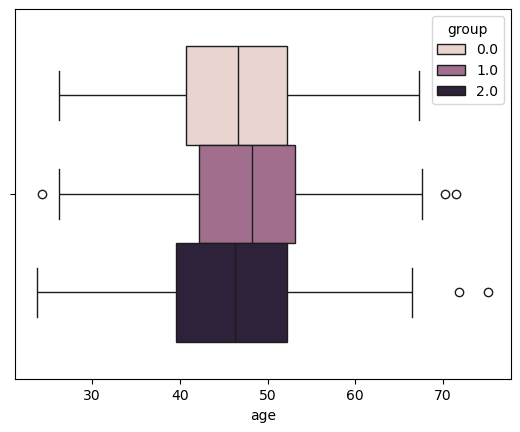

In [5]:
#2. visualizing the distribution of age, income, and sex of thebank customer, split by the different 
#treatments.
# age
sns.boxplot(x='age',hue='group',data=card)
plt.show()


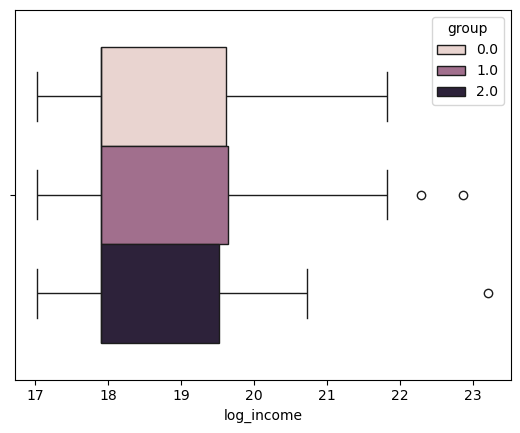

In [ ]:
# income
card['log_income'] = np.log(card['income']) # we take the log of income to make the 
#distribution more normal and add it as a new column to the dataframe
sns.boxplot(x='log_income',hue='group',data=card)
plt.show()

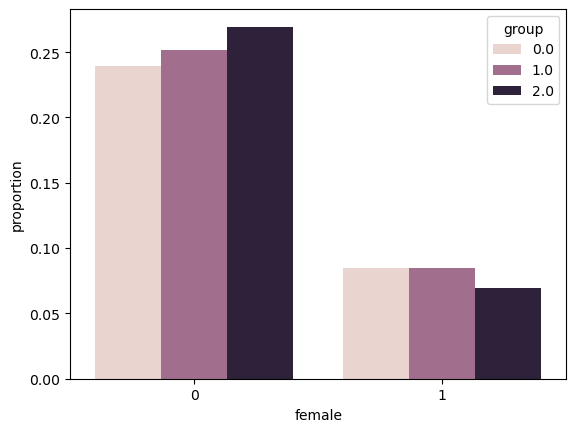

In [9]:
#sex
sns.countplot(x='female',hue='group',data=card,stat='proportion')
plt.show()

In [ ]:
# 3. perform a formal hypothesis test  of whether or not the expected age in the control group 
# is different from the expected age in the treatment group.
# We can use a two-sample t-test to compare the means of the two groups.
age0 = card.query("group==0")["age"] #.qyuery is a method that allows us to filter the dataframe based on a
#condition. Here we are filtering the dataframe to get the age of the customers in the control group 
#(group==0).
age1 = card.query("group==1")["age"]
test = stats.ttest_ind(age0, age1, alternative = "two-sided")
print(test)